# DART 이벤트 스터디 — 결과 리포트

**유니버스**: KOSPI 시총 상위 200 보통주 (현재 스냅샷 근사 — 한계 참조) · **기간**: 2019-01-01 ~ 2024-12-31

**이벤트 3종**: 자사주매입(직접취득) / 유상증자 / 실적공시(잠정실적)

**핵심 설계**: 여론 감성이 아니라 공시의 **구조화 정보 + 방향 룰**. Look-ahead 방지를 위해 모든 시그널은
접수일 **익영업일 종가** 체결 가정(접수시각 미제공 — 보수적), 수정주가 사용, 거래비용(거래세 0.20% + 슬리피지 0.10% 편도) 반영.

**재현**: 레포 루트에서 `uv sync` → `.env`에 `OPENDART_API_KEY` → 파이프라인 5단계 실행(README 참조) 후 이 노트북 실행.
모든 원천 응답은 `data/`에 캐시되므로 재실행이 빠르다.

In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import yaml

DATA = Path("..") / "data"
MODE = "full"

# 차트 팔레트 — dataviz 검증기 통과 (CVD ΔE 16.2, aqua는 직접 라벨로 보완)
C_BLUE, C_AQUA, C_RED, C_ORANGE = "#2a78d6", "#1baf7a", "#e34948", "#eb6834"
INK, MUTED, GRID, BASE = "#0b0b0b", "#898781", "#e1e0d9", "#c3c2b7"
mpl.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": BASE, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.sans-serif": ["Malgun Gothic", "DejaVu Sans"], "axes.unicode_minus": False,
})

events = pd.read_parquet(DATA / f"events_{MODE}.parquet")
signals = pd.read_parquet(DATA / f"signals_{MODE}.parquet")
car = pd.read_parquet(DATA / f"eventstudy_{MODE}" / "car_summary.parquet")
aar = pd.read_parquet(DATA / f"eventstudy_{MODE}" / "aar_curves.parquet")
bt = pd.read_parquet(DATA / f"backtest_{MODE}.parquet")
settings = yaml.safe_load((Path("..") / "config" / "settings.yaml").read_text(encoding="utf-8"))
print(f"이벤트 {len(events):,}건 / 시그널 {len(signals):,}건")

이벤트 5,078건 / 시그널 4,370건


## 1. 표본 (전부 공개 — 다중검정 원칙)

이벤트별 표본 수와 방향 분포. 실적 방향 판정 불가 13.7%는 원문 미제공(구형 공시) + 표 형식 변형 때문이며 시그널에서 제외했다.
서프라이즈 기준은 영업이익 YoY가 기본, 전년동기 결측 시 QoQ 폴백(`surprise_basis`에 기록).

In [2]:
tbl = events.pivot_table(index="event_type", columns="direction", values="rcept_no",
                         aggfunc="count", dropna=False, fill_value=0)
tbl["판정불가"] = events[events["direction"].isna()].groupby("event_type").size()
tbl["합계"] = events.groupby("event_type").size()
display(tbl.fillna(0).astype(int))
print("실적 서프라이즈 기준:", events[events.event_type == "earnings"]["surprise_basis"].value_counts(dropna=False).to_dict())

direction,-1.0,0.0,1.0,NaN,판정불가,합계
event_type,,,,,,
buyback,0,0,174,0,0,174
earnings,1742,1,2401,659,659,4803
rights_offering,46,43,12,0,0,101


실적 서프라이즈 기준: {'yoy': 4076, nan: 659, 'qoq': 68}


## 2. 이벤트 스터디 — 정보력은 실재한다

시장모형(KOSPI, 추정 120거래일·갭 10일) 잔차의 누적 평균(CAAR). day 0 = 접수일 이후 첫 거래일.

C:\Users\luis2\AppData\Local\Temp\ipykernel_38136\4203555301.py:21: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\luis2\OneDrive\바탕 화면\quant-lab\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


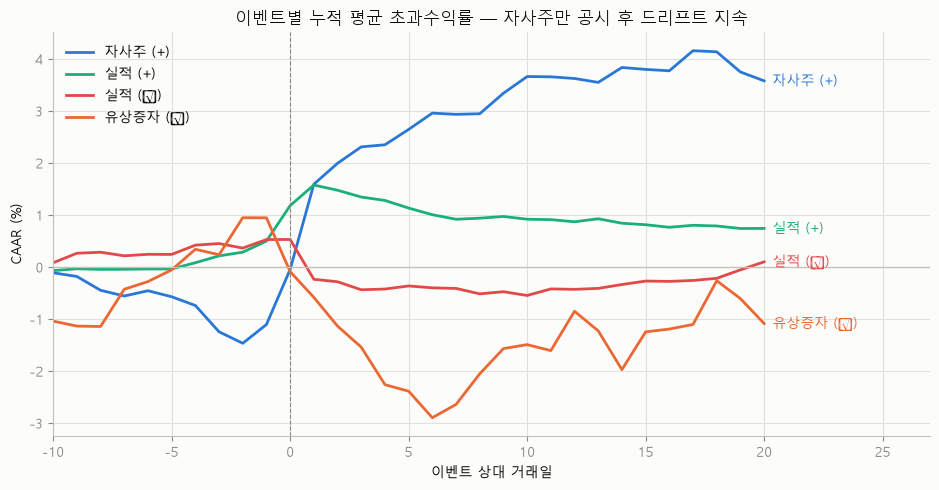

In [3]:
groups = {
    ("buyback", 1): ("자사주 (+)", C_BLUE),
    ("earnings", 1): ("실적 (+)", C_AQUA),
    ("earnings", -1): ("실적 (−)", C_RED),
    ("rights_offering", -1): ("유상증자 (−)", C_ORANGE),
}
fig, ax = plt.subplots(figsize=(9.5, 5))
for (et, d), (label, color) in groups.items():
    g = aar[(aar.event_type == et) & (aar.direction == d)].sort_values("rel_day")
    caar = g.set_index("rel_day")["aar"].cumsum() * 100
    ax.plot(caar.index, caar.values, color=color, linewidth=2, label=label)
    ax.annotate(label, (caar.index[-1], caar.iloc[-1]), xytext=(6, 0),
                textcoords="offset points", color=color, fontsize=10, va="center")
ax.axvline(0, color=MUTED, linewidth=0.8, linestyle="--")
ax.axhline(0, color=BASE, linewidth=1)
ax.set_xlabel("이벤트 상대 거래일")
ax.set_ylabel("CAAR (%)")
ax.set_title("이벤트별 누적 평균 초과수익률 — 자사주만 공시 후 드리프트 지속")
ax.legend(frameon=False, loc="upper left")
ax.set_xlim(-10, 27)
plt.tight_layout()
plt.show()

In [4]:
t = car.copy()
t["mean_car(%)"] = (t["mean_car"] * 100).round(2)
t["pos_ratio"] = t["pos_ratio"].round(2)
t[["t", "p"]] = t[["t", "p"]].round(3)
t["유의(5%)"] = (t["p"] < 0.05).map({True: "✓", False: ""})
t["표본유보"] = t["thin_sample"].map({True: "⚠️", False: ""})
display(t[["event_type", "direction", "window", "N", "mean_car(%)", "pos_ratio", "t", "p", "유의(5%)", "표본유보"]])

,event_type,direction,window,N,mean_car(%),pos_ratio,t,p,유의(5%),표본유보
0,buyback,1,"[-1,1]",166,3.06,0.77,8.063,0.000,✓,
1,buyback,1,"[0,5]",166,3.75,0.76,6.986,0.000,✓,
2,buyback,1,"[0,20]",166,4.68,0.66,5.287,0.000,✓,
3,earnings,-1,"[-1,1]",1664,-0.60,0.43,-4.808,0.000,✓,
4,earnings,-1,"[0,5]",1664,-0.89,0.41,-5.603,0.000,✓,
5,earnings,-1,"[0,20]",1664,-0.43,0.48,-1.623,0.105,,
6,earnings,1,"[-1,1]",2325,1.29,0.58,11.606,0.000,✓,
7,earnings,1,"[0,5]",2325,0.63,0.53,4.450,0.000,✓,
8,earnings,1,"[0,20]",2325,0.24,0.50,1.033,0.302,,
9,rights_offering,-1,"[-1,1]",36,-1.53,0.33,-1.285,0.207,,


## 3. 백테스트 — 체결가능 수익은 비용이 가른다

익영업일 종가 진입, H거래일 보유, 동시 포지션 균등가중, |Δw| 기반 비용 차감.
아래 NAV는 자사주-only(H=5), 전체 시그널(H=5), KOSPI 벤치마크.

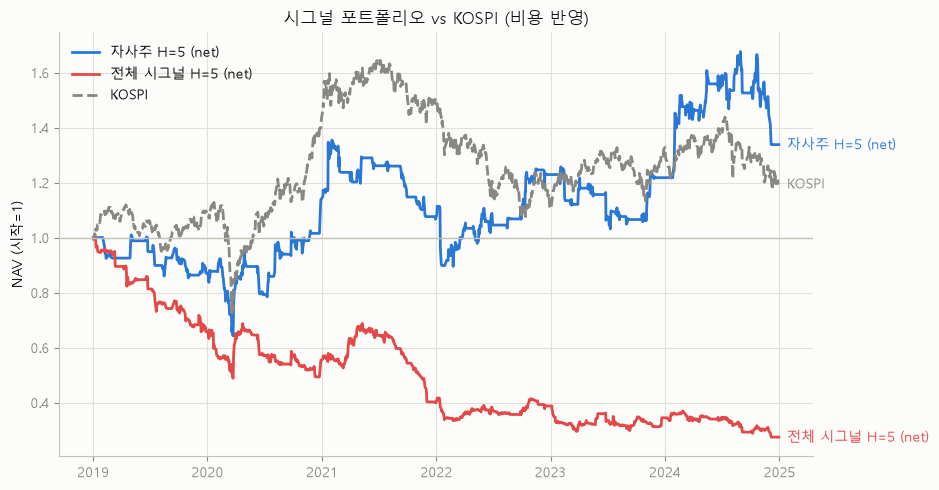

In [5]:
from quantlab_shared.backtest.costs import CostModel
from quantlab_shared.backtest.engine import run_backtest
from quantlab_shared.data.prices import PriceStore

start, end = settings["period"]["start"], settings["period"]["end"]
cost = CostModel(settings["costs"]["transaction_tax"], settings["costs"]["slippage"])
store = PriceStore(DATA / "prices", start, end)
closes = pd.DataFrame({tk: store.ohlcv(tk)["close"] for tk in signals["ticker"].unique()})

res_bb = run_backtest(signals[signals.event_type == "buyback"], closes, 5, cost)
res_all = run_backtest(signals, closes, 5, cost)
kospi_ret = store.ohlcv("KS11")["close"].pct_change().fillna(0)

fig, ax = plt.subplots(figsize=(9.5, 5))
for daily, label, color, style in [
    (res_bb.daily_net, "자사주 H=5 (net)", C_BLUE, "-"),
    (res_all.daily_net, "전체 시그널 H=5 (net)", C_RED, "-"),
    (kospi_ret, "KOSPI", MUTED, "--"),
]:
    nav = (1 + daily).cumprod()
    ax.plot(nav.index, nav.values, color=color, linewidth=2, linestyle=style, label=label)
    ax.annotate(label, (nav.index[-1], nav.iloc[-1]), xytext=(6, 0),
                textcoords="offset points", color=color, fontsize=10, va="center")
ax.axhline(1, color=BASE, linewidth=1)
ax.set_ylabel("NAV (시작=1)")
ax.set_title("시그널 포트폴리오 vs KOSPI (비용 반영)")
ax.legend(frameon=False, loc="upper left")
plt.tight_layout()
plt.show()

In [6]:
cols = ["scope", "H", "variant", "ann_return", "sharpe", "sortino", "mdd", "turnover_ann", "hit_ratio", "n_trades"]
display(bt[cols].round(3))

,scope,H,variant,ann_return,sharpe,sortino,mdd,turnover_ann,hit_ratio,n_trades
0,all,5,long_short,-0.198,-0.912,-1.149,-0.726,55.791,0.451,4360.0
1,all(gross),5,long_short,0.002,0.011,0.014,-0.428,55.791,0.451,4360.0
2,all,5,long_only,-0.156,-0.633,-0.807,-0.640,51.207,0.445,2582.0
3,all(gross),5,long_only,0.036,0.147,0.183,-0.433,51.207,0.445,2582.0
4,buyback,5,long_short,0.051,0.214,0.227,-0.363,24.608,0.550,171.0
5,buyback,5,long_only,0.051,0.214,0.227,-0.363,24.608,0.550,171.0
6,earnings,5,long_short,-0.203,-1.398,-1.342,-0.741,44.041,0.446,4143.0
7,earnings,5,long_only,-0.158,-0.810,-0.821,-0.655,41.286,0.437,2401.0
8,rights_offering,5,long_short,0.006,0.038,0.019,-0.435,7.683,0.609,46.0
9,rights_offering,5,long_only,0.007,0.098,0.033,-0.177,1.707,0.500,10.0


## 4. 결론 (정직 버전)

1. **공시의 정보력은 실재한다.** 방향 룰의 부호는 세 이벤트 모두 시장 반응과 일치하고,
   자사주 +4.7%(t=5.3, [0,+20]), 실적± 공시창 반응, 유증 −3.3%([0,+5])가 유의하다.
2. **그러나 체결가능한 초과수익은 대부분 사라진다.** 익영업일 진입(보수적 타이밍)이 공시창
   점프를 놓치고, 왕복 0.4% 비용이 잦은 실적 시그널을 전멸시킨다 (gross 연 +14.4% → net +0.7%).
3. **자사주 이벤트만 생존.** H=5 net 연 +5.1%, Sharpe 0.21 (KOSPI +3.1%, 0.16) — 우위는 미미하며
   MDD −36%를 감안하면 단독 전략으로 매력적이라 말하기 어렵다.
4. 이 괴리(정보력 vs 체결가능성)의 정량화가 이 프로젝트의 기여다.

### 한계
- 유니버스 = 시총 상위 200 **현재 스냅샷** (KOSPI200 근사, survivorship bias — KRX API 봇차단으로 불가피)
- 접수시각 미확보 → 전 건 익영업일 체결 (당일 체결 기회를 버리는 보수적 편향)
- 실적 이벤트 13.7% 방향 판정 불가 (원문 미제공·표 형식 변형)
- 유상증자 표본 101건 중 방향성 시그널 58건 — 배정방식별 세분 시 표본 얇음, 숏 현실성 미반영
- 컨센서스 부재 → 서프라이즈는 YoY(폴백 QoQ) 대용치